Loaded 11,903 events from /content/gdelt_cleaned (2).csv
Year range: 2020-2024

Per year:
year
2020    2579
2021    2414
2022    2115
2023    2469
2024    2326


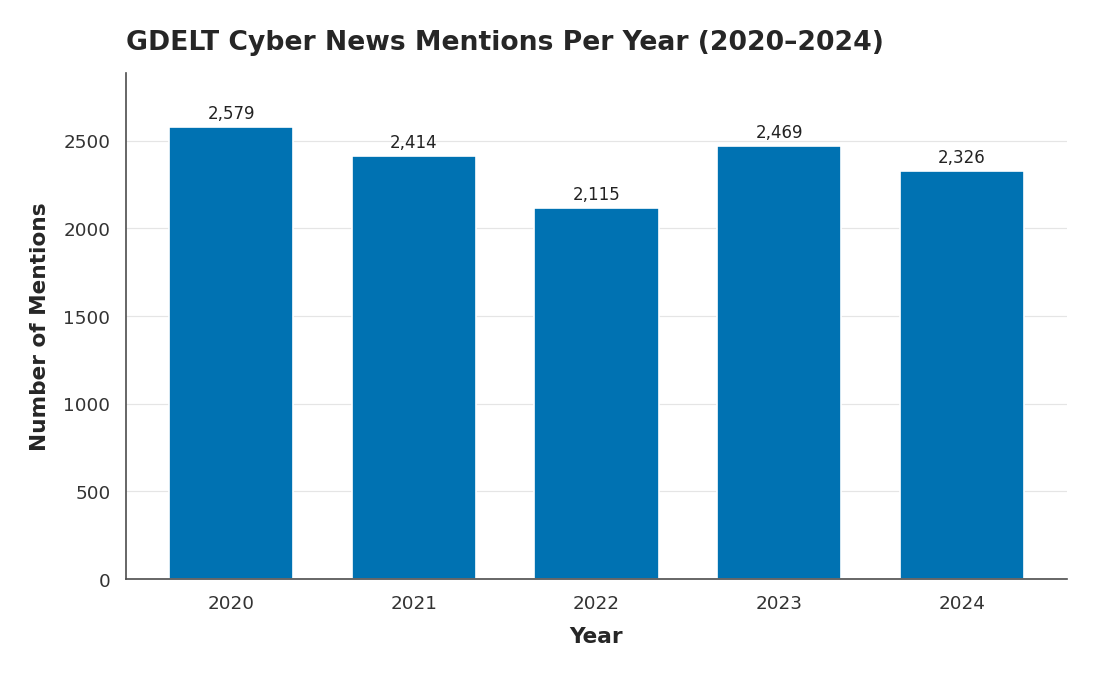


Per month (all years combined):
month
1      826
2     1016
3     1064
4     1111
5     1074
6     1039
7     1070
8      867
9      975
10    1131
11     878
12     852


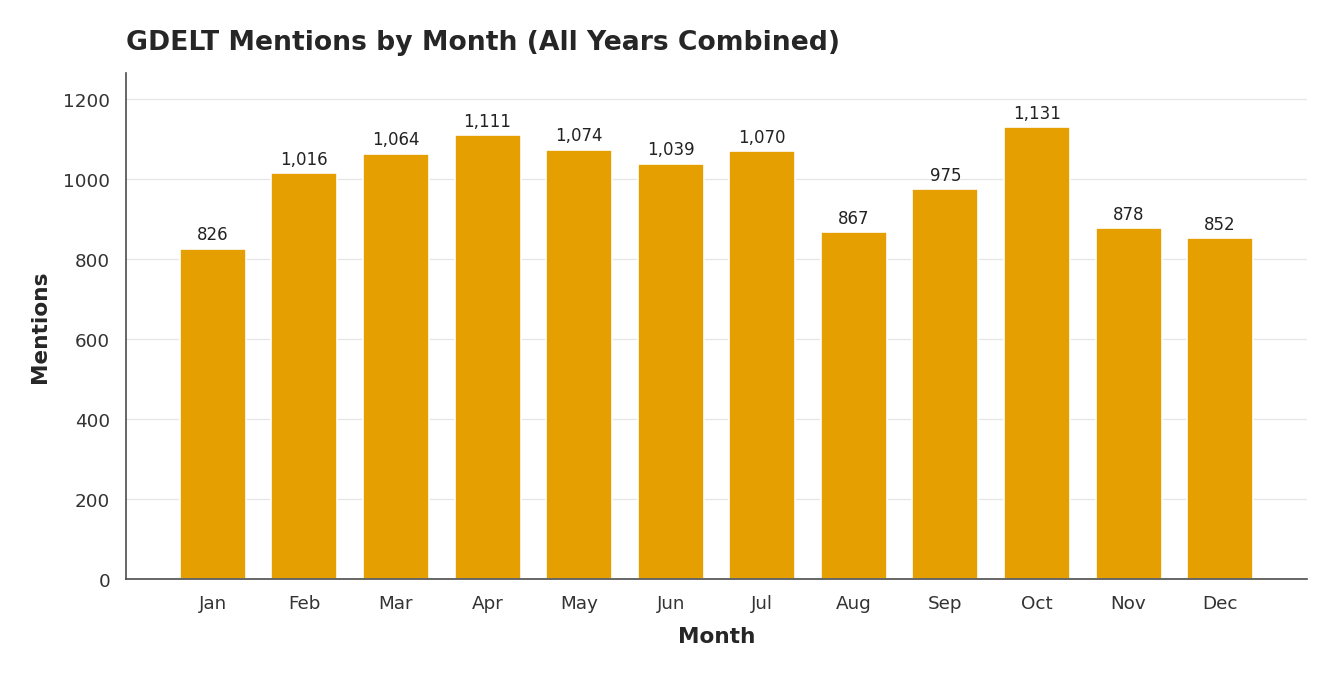


Done. 2 figures written to: /content/figures
  figure1_mentions_per_year.png
  figure11_mentions_by_month.png


In [4]:
"""
================================================================================
PRESTIGE PARADOX — FIGURES 1 & 11 (event-level time series)
================================================================================
Regenerates the two GDELT event-level figures from the cleaned event export:

    Figure 1  : Annual distribution of GDELT cybersecurity news mentions,
                2020-2024 (blue bars, one bar per year)
    Figure 11 : Monthly time series of GDELT cybersecurity mentions, all years
                combined, January - December (orange bars, one bar per month)

Figures are saved as PNGs AND displayed inline in the output cell.
================================================================================
"""

import os
import calendar

import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ---- paths (edit these) -----------------------------------------------------
INPUT_CSV = "/content/gdelt_cleaned (2).csv"
FIG_DIR   = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


# =========================================================== VISUAL THEME ===
PALETTE = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
}

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "savefig.facecolor":  "white",
    "figure.dpi":         120,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.25,
    "font.family":        "DejaVu Sans",
    "font.size":          12,
    "axes.titlesize":     16,
    "axes.titleweight":   "bold",
    "axes.titlepad":      14,
    "axes.labelsize":     13,
    "axes.labelweight":   "bold",
    "axes.labelpad":      8,
    "axes.edgecolor":     "#4D4D4D",
    "axes.linewidth":     1.0,
    "grid.color":         "#CCCCCC",
    "grid.linewidth":     0.7,
    "grid.alpha":         0.5,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,
    "xtick.color":        "#333333",
    "ytick.color":        "#333333",
})

def _style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#4D4D4D")
    ax.grid(axis="x", alpha=0.0)
    ax.grid(axis="y", color="#CCCCCC", linewidth=0.7, alpha=0.5)
    ax.set_axisbelow(True)

def _label_barv(ax, fmt="{:,.0f}", pad=3, size=10):
    ymax = 0
    for p in ax.patches:
        ymax = max(ymax, p.get_height())
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(fmt.format(h),
                    xy=(p.get_x() + p.get_width() / 2, h),
                    xytext=(0, pad), textcoords="offset points",
                    va="bottom", ha="center", fontsize=size, color="#222222")
    ax.set_ylim(top=ymax * 1.12)


# =============================================================== LOAD DATA ===
df = pd.read_csv(INPUT_CSV)
N = len(df)
print(f"Loaded {N:,} events from {INPUT_CSV}")
print(f"Year range: {int(df['year'].min())}-{int(df['year'].max())}")


# ============================================================== FIGURE 1 =====
yearly = df["year"].value_counts().sort_index()
print("\nPer year:\n" + yearly.to_string())

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(yearly.index.astype(int).astype(str), yearly.values,
       color=PALETTE["blue"], edgecolor="white", linewidth=1.0, width=0.68)
ax.set_title("GDELT Cyber News Mentions Per Year (2020–2024)", loc="left")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Mentions")
_style_axes(ax)
_label_barv(ax, fmt="{:,.0f}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/figure1_mentions_per_year.png")
plt.show()


# ============================================================= FIGURE 11 =====
monthly = df["month"].value_counts().sort_index()
monthly = monthly.reindex(range(1, 13), fill_value=0)
print("\nPer month (all years combined):\n" + monthly.to_string())

month_labels = [calendar.month_abbr[m] for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(month_labels, monthly.values,
       color=PALETTE["orange"], edgecolor="white", linewidth=1.0, width=0.72)
ax.set_title("GDELT Mentions by Month (All Years Combined)", loc="left")
ax.set_xlabel("Month")
ax.set_ylabel("Mentions")
_style_axes(ax)
_label_barv(ax, fmt="{:,.0f}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/figure11_mentions_by_month.png")
plt.show()

print(f"\nDone. 2 figures written to: {os.path.abspath(FIG_DIR)}")
print("  figure1_mentions_per_year.png")
print("  figure11_mentions_by_month.png")